In [1]:
import random
from PIL import Image, ImageDraw, ImageFont
import numpy as np

def generate_random_circle(shape=(32, 32, 3), dtype=np.float32):
    d = random.randint(3, int(0.5 * min(shape[0], shape[1]))) # diameter
    x0, y0 = random.uniform(0, shape[1]-d), random.uniform(0, shape[0]-d) # top left
    x1, y1 = x0 + d, y0 + d # bottom right

    img_in = Image.fromarray(np.full(shape, 255, 'uint8')) # blank image
    img_out = Image.fromarray(np.full(shape[:2], 0, 'uint8')) # blank image: class 0

    draw_in = ImageDraw.Draw(img_in)
    draw_in.ellipse((x0, y0, x1, y1), outline='red', width=1) # input image
    draw_out = ImageDraw.Draw(img_out)
    draw_out.ellipse((x0, y0, x1, y1), outline=1, fill=1, width=1) # output image; class 1

    input = np.array(img_in).astype(dtype)
    output = np.array(img_out).astype(dtype)

    return input, output

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


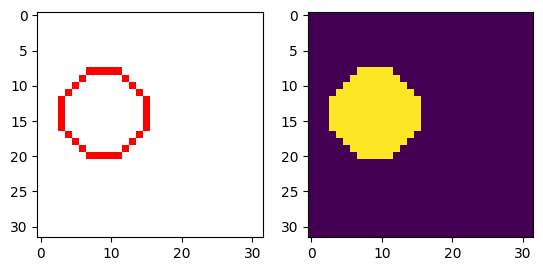

In [8]:
if __name__=='__main__':
    import matplotlib.pyplot as plt

    image_shape = (32, 32, 3)
    input, output = generate_random_circle(shape=image_shape)

    plt.subplot(1,2,1)
    # plt.imshow(img_in)
    plt.imshow(input)
    plt.subplot(1,2,2)
    # plt.imshow(img_out)
    plt.imshow(output)
    plt.show()

- dataset preparation for pytorch

In [ ]:
if __name__=='__main__':
    # from image.datasets import segmentation
    import numpy as np
    import torch

    def generate_random_bacth_data(batch_size = 4, image_shape = (32, 32, 3)):
        data_in, data_out = [], []
        for _ in range(batch_size):
            # input, output = segmentation.generate_random_circle(shape=image_shape)
            input, output = generate_random_circle(shape=image_shape)

            data_in.append(np.expand_dims(input.transpose(2,0,1), axis=0))
            data_out.append(np.expand_dims(output, axis=0))
        inputs = torch.from_numpy(np.concatenate(data_in, axis=0))
        outputs = torch.from_numpy(np.concatenate(data_out, axis=0))
        return inputs, outputs

    example_ins, example_outs = generate_random_bacth_data(batch_size = 1)
    print(f'example_ins.shape = {example_ins.shape}; example_outs.shape = {example_outs.shape}')
    print(example_ins.type())